In [1]:
# Importações

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from src.config import CLEANED_DATA, DUMMIES_DATA
from src.graphics import pairplot, plot_bivariate_boxplot, plot_corr_barplot
from src.utils import inspect_outliers

In [2]:
# Obtendo os dados como DataFrame
df = pd.read_parquet(CLEANED_DATA)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,YearsSinceEnrolled,Age,MntTotal,MntRegularProds,Children,hasChildren,AcceptedCmpTotal,HasAcceptedCmp,NumPurchasesTotal,AgeGroup
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,1,57,1617,1529,0,0,0,0,22,46-60
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,60,27,21,2,1,0,0,4,46-60
2,Graduation,Partner,71613.0,0,0,26,426,49,127,111,...,0,49,776,734,0,0,0,0,20,46-60
3,Graduation,Partner,26646.0,1,0,26,11,4,20,10,...,0,30,53,48,1,1,0,0,6,18-30
4,PhD,Partner,58293.0,1,0,94,173,43,118,46,...,0,33,422,407,1,1,0,0,14,31-45


In [3]:
# Resumo da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Education            2194 non-null   object  
 1   Marital_Status       2194 non-null   object  
 2   Income               2194 non-null   float64 
 3   Kidhome              2194 non-null   int64   
 4   Teenhome             2194 non-null   int64   
 5   Recency              2194 non-null   int64   
 6   MntWines             2194 non-null   int64   
 7   MntFruits            2194 non-null   int64   
 8   MntMeatProducts      2194 non-null   int64   
 9   MntFishProducts      2194 non-null   int64   
 10  MntSweetProducts     2194 non-null   int64   
 11  MntGoldProds         2194 non-null   int64   
 12  NumDealsPurchases    2194 non-null   int64   
 13  NumWebPurchases      2194 non-null   int64   
 14  NumCatalogPurchases  2194 non-null   int64   
 15  NumStorePurchases    

In [4]:
# Resumo estatístico das colunas numéricas
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,DaysSinceEnrolled,YearsSinceEnrolled,Age,MntTotal,MntRegularProds,Children,hasChildren,AcceptedCmpTotal,HasAcceptedCmp,NumPurchasesTotal
count,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,...,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000
mean,51941.864175,0.442571,0.503646,49.373291,303.232452,26.463993,167.068824,37.655424,27.171832,43.643573,...,352.634913,0.481768,45.145852,605.236098,561.592525,0.946217,0.713309,0.294895,0.203282,12.547858
std,21457.702015,0.539064,0.545458,28.922521,335.470174,39.845333,224.989599,54.539708,41.288991,51.674784,...,201.623385,0.499781,11.711833,600.538786,575.043846,0.751849,0.452319,0.679383,0.402532,7.208430
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,18.000000,5.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35461.500000,0.000000,0.000000,25.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,180.250000,0.000000,37.000000,69.000000,55.250000,0.000000,0.000000,0.000000,0.000000,6.000000
50%,51117.500000,0.000000,0.000000,50.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.000000,...,353.000000,0.000000,44.000000,395.500000,341.000000,1.000000,1.000000,0.000000,0.000000,12.000000
75%,68385.750000,1.000000,1.000000,74.000000,503.750000,33.000000,233.750000,50.000000,33.750000,56.000000,...,527.500000,1.000000,55.000000,1041.500000,961.750000,1.000000,1.000000,0.000000,0.000000,18.750000
max,162397.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,...,699.000000,1.000000,74.000000,2524.000000,2491.000000,3.000000,1.000000,4.000000,1.000000,32.000000


In [5]:
# Resumo estatístico das colunas categóricas
df.describe(exclude="number")

,Education,Marital_Status,AgeGroup
count,2194,2194,2194
unique,5,2,4
top,Graduation,Partner,31-45
freq,1115,1420,955


Iremos analisar o comportamento de algumas colunas a partir de pairplots, destacando os pontos de determinadas categorias em uma coluna categórica.

In [6]:
# Colunas de análise

analysis_columns = [
    "Income",
    "Recency",
    "DaysSinceEnrolled",
    "Age",
    "MntTotal"
]

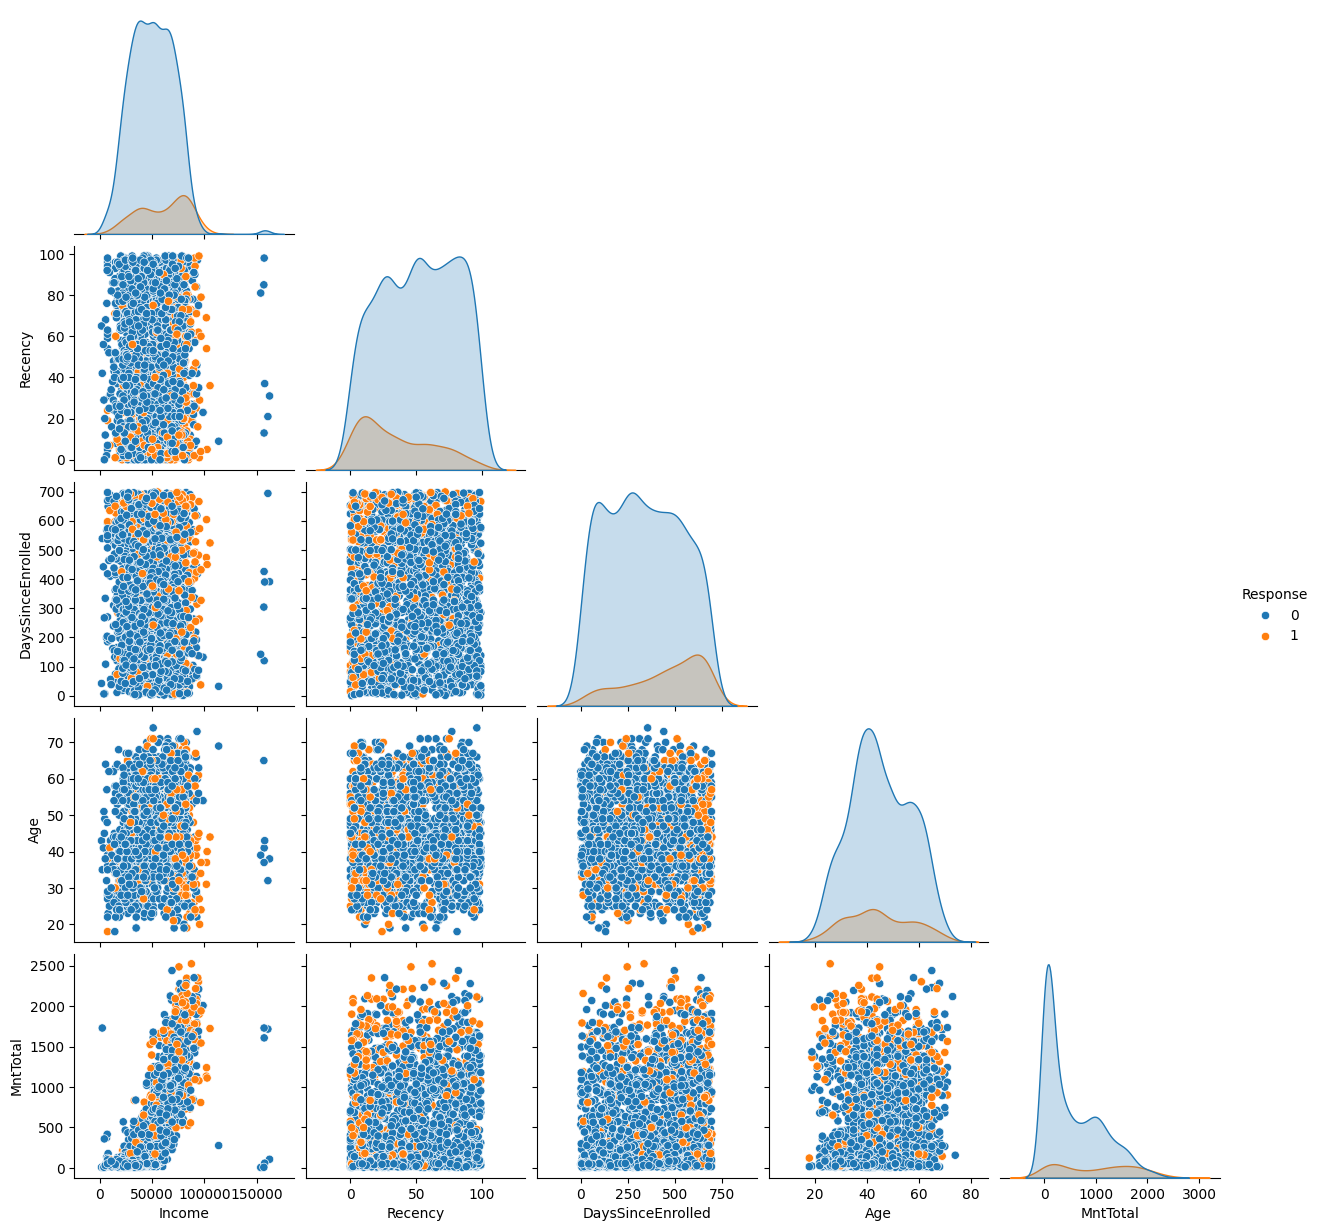

In [7]:
# Analisando pairplot para cada valor de Response
pairplot(df, analysis_columns, "Response")

- Concentração de registros com `Response` 1 em valores maiores de `Income`
- Concentração de registros com `Response` 1 em valores menores de `Recency`
- Concentração de registros com `Response` 1 em valores maiores de `DaysSinceEnrolled`
- Concentração de registros com `Response` 0 em valores pequenos de `MntTotal`

Podemos observar também poucas ocorrências em valores grandes de `Income` para a classe 0 de `Response`.

Esses valores correspondem aos demais outliers que não foram removidos anteriormente de `Income`.

Esses registros podem levar a captura de ruído indesejável. Logo, optarei por removê-los, apesar deles não parecerem errôneios.

In [8]:
# Removendo os outliers de Income

remove_indexes = inspect_outliers(df, "Income").index

df = df[~(df.index.isin(remove_indexes))].reset_index(drop=True)

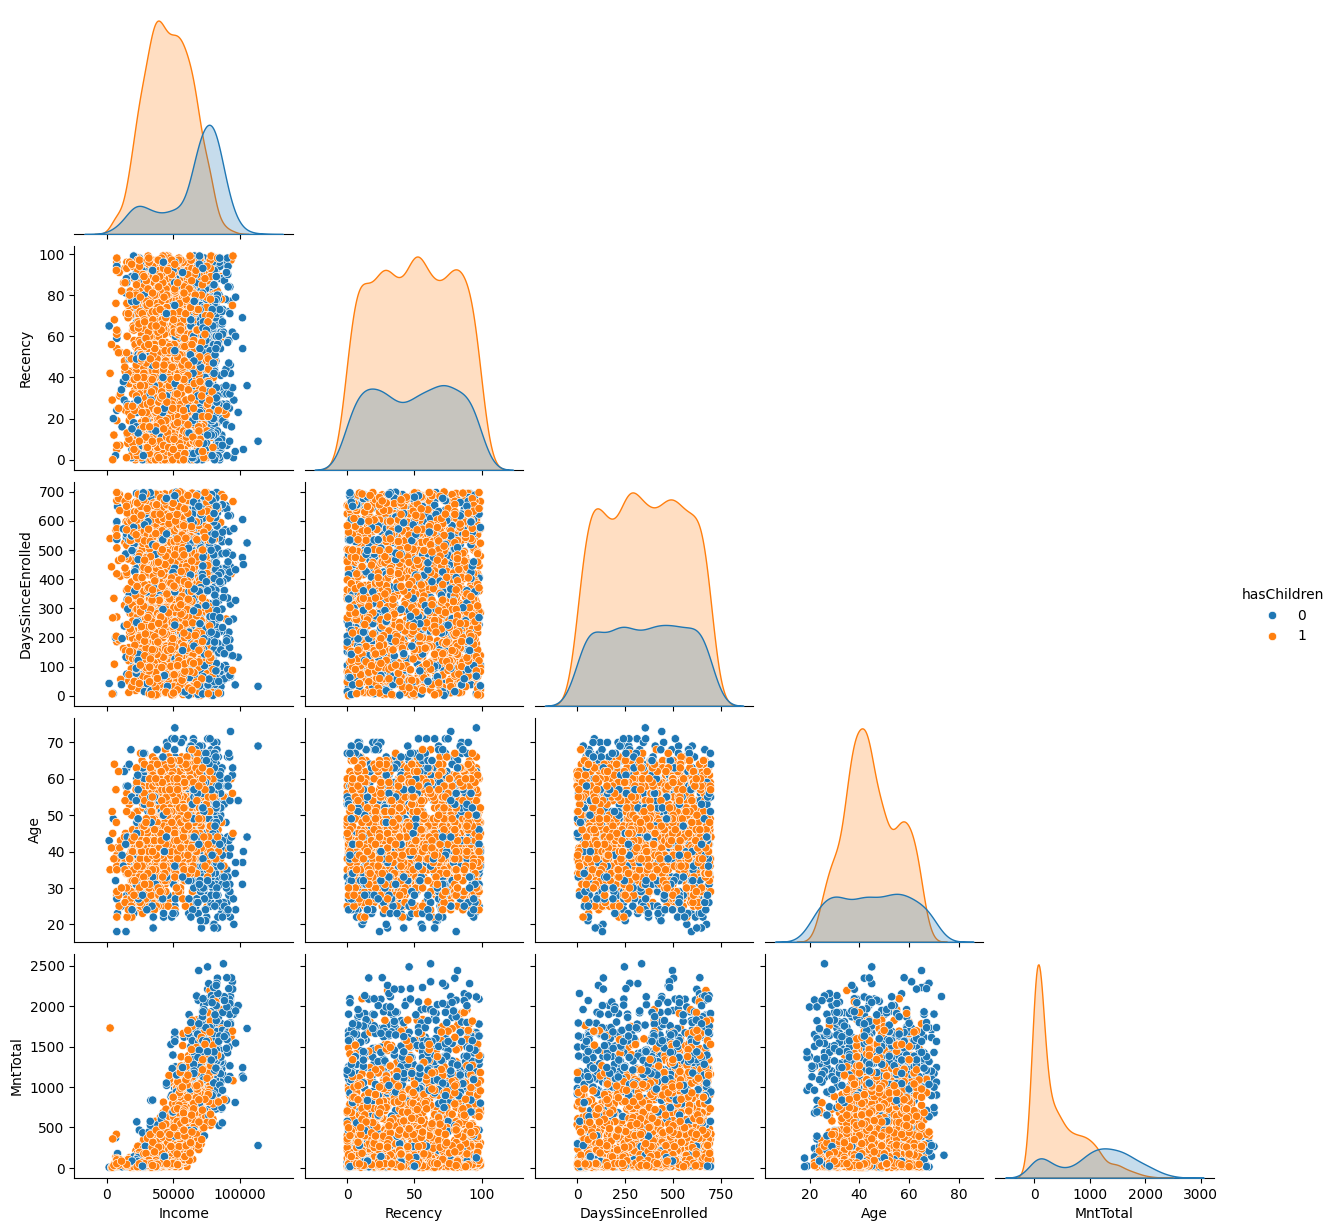

In [9]:
# Analisando o pairplot para cada valor de hasChildren
pairplot(df, analysis_columns, "hasChildren") 

- Concentração de registros da categoria 0 de `hasChildren` em valores maiores de `Income`
- Concentração de registros da categoria 1 de `hasChildren` em valores pequenos de `MntTotal`

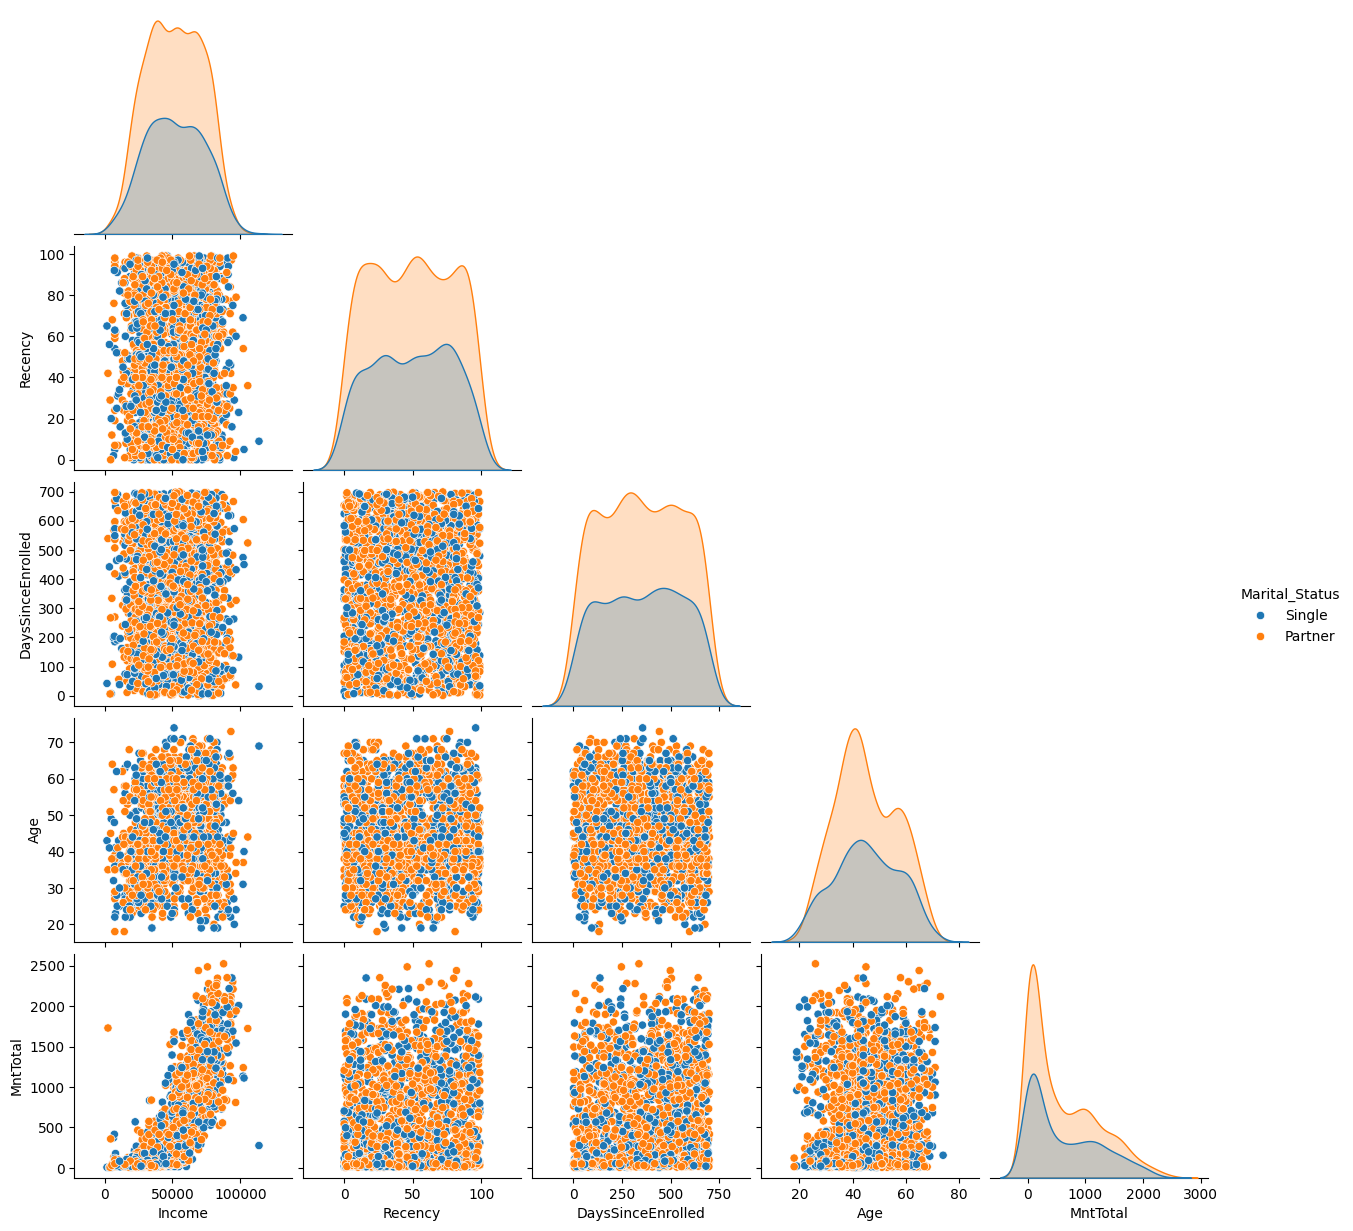

In [10]:
# Analisando pairplot para cada valor de Marital_Status
pairplot(df, analysis_columns, "Marital_Status")

Existe pouca diferença entre as categorias de `Marital_Status`.

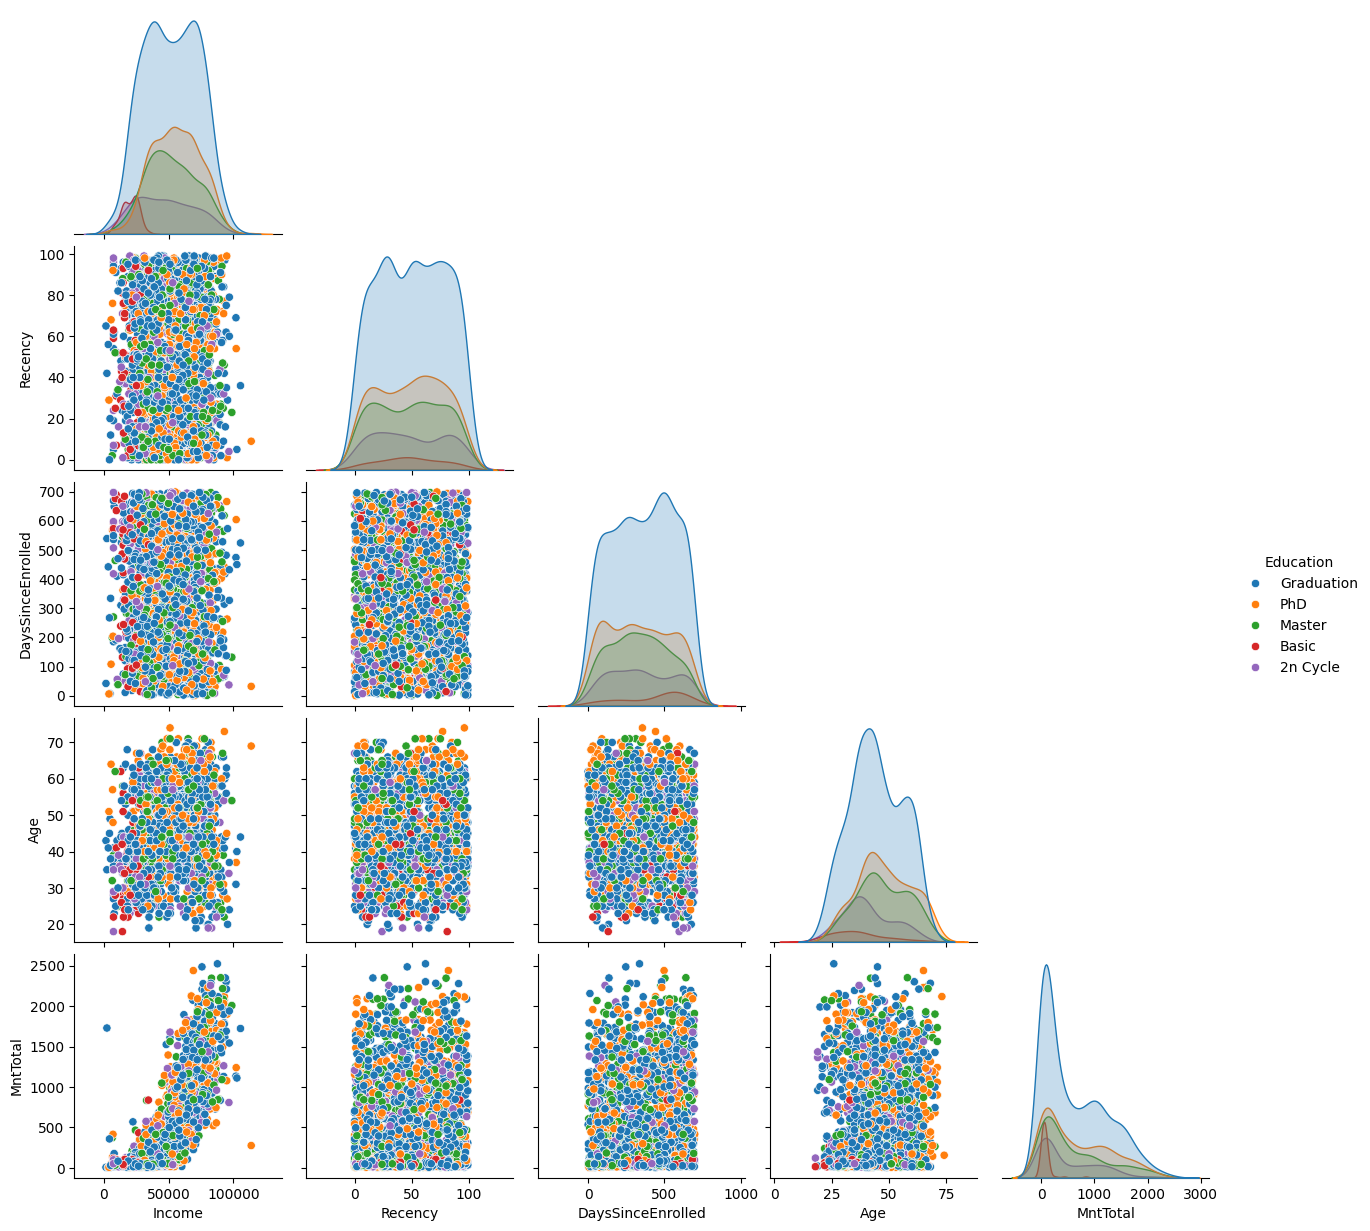

In [11]:
# Analisando pairplot para cada valor de Education
pairplot(df, analysis_columns, "Education")

- Concentração em valores pequenos de `Income` para registros categorizados como 'Basic' em `Education`
- Concentração em valores pequenos de `MntTotal` para registros categorizados como 'Basic' em `Education`

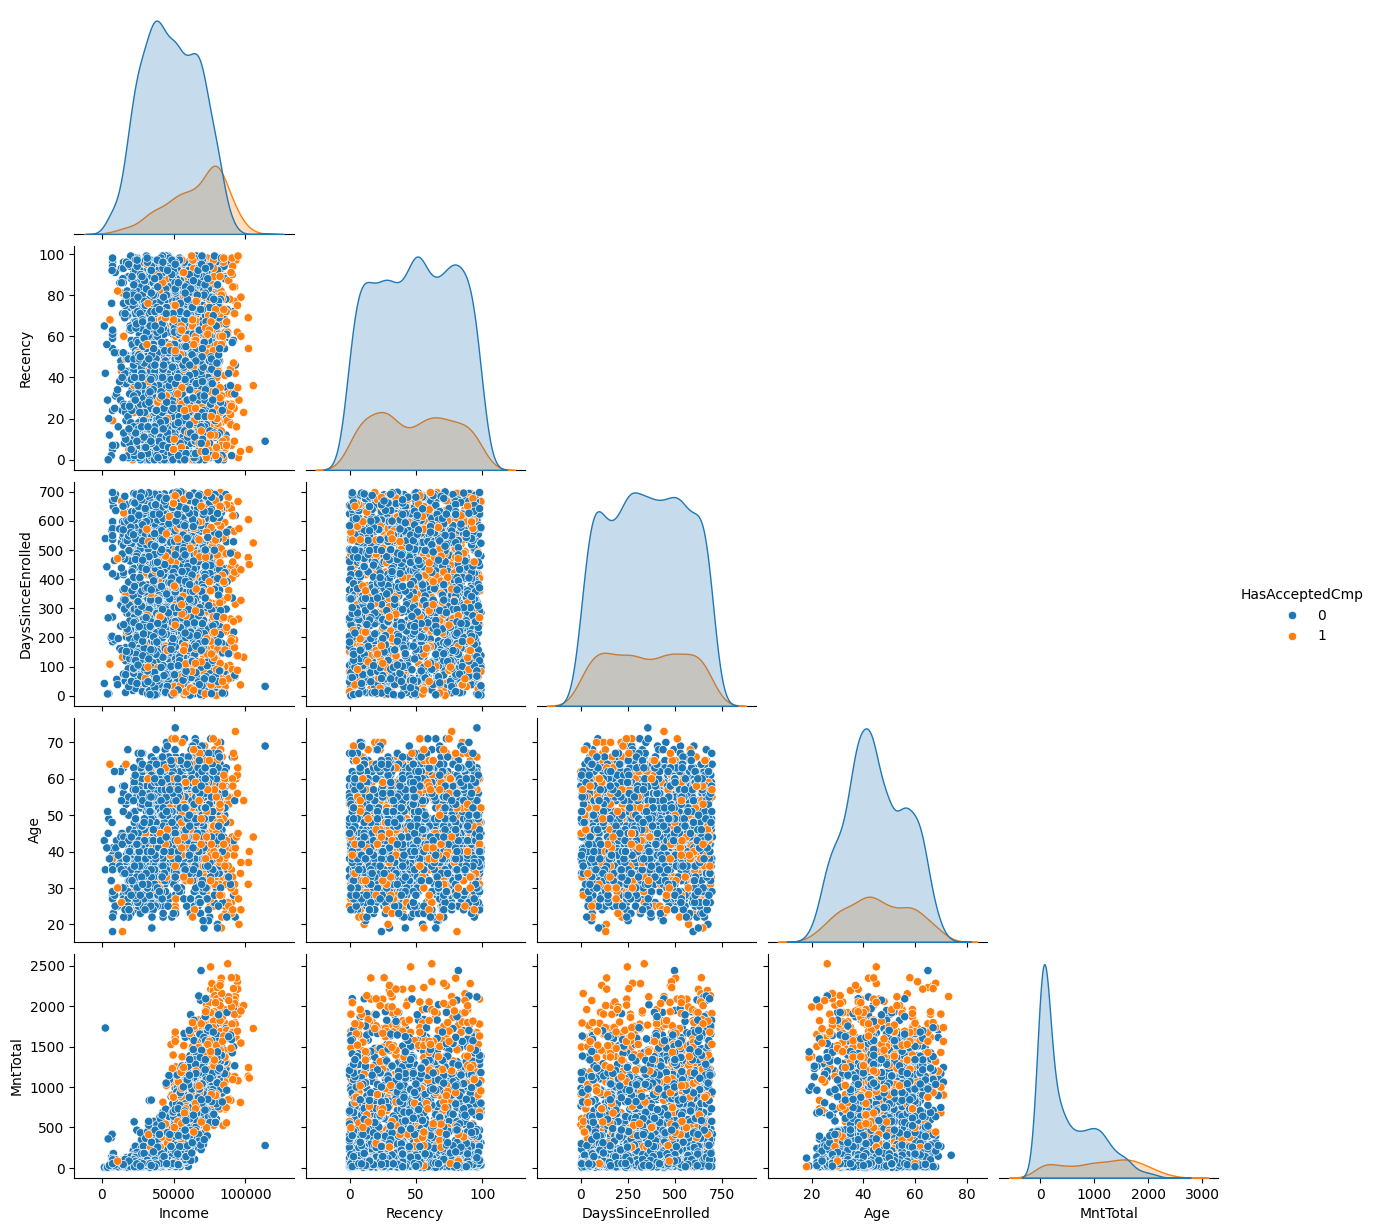

In [12]:
# Analisando pairplot para cada valor de HasAcceptedCmp
pairplot(df, analysis_columns, "HasAcceptedCmp")

- Concentração em valores maiores de `Income` para registros de categoria 1 em `HasAcceptedCmp`
- Concentração em valores menores de `Income` para registros de categoria 0 em `HasAcceptedCmp`
- Quantidade de registros da classe 1 de `HasAcceptedCmp` considerável em valores grandes de `MntTotal`
- Concentração em valores menores de `MntTotal` para registros de categoria 0 em `HasAcceptedCmp`

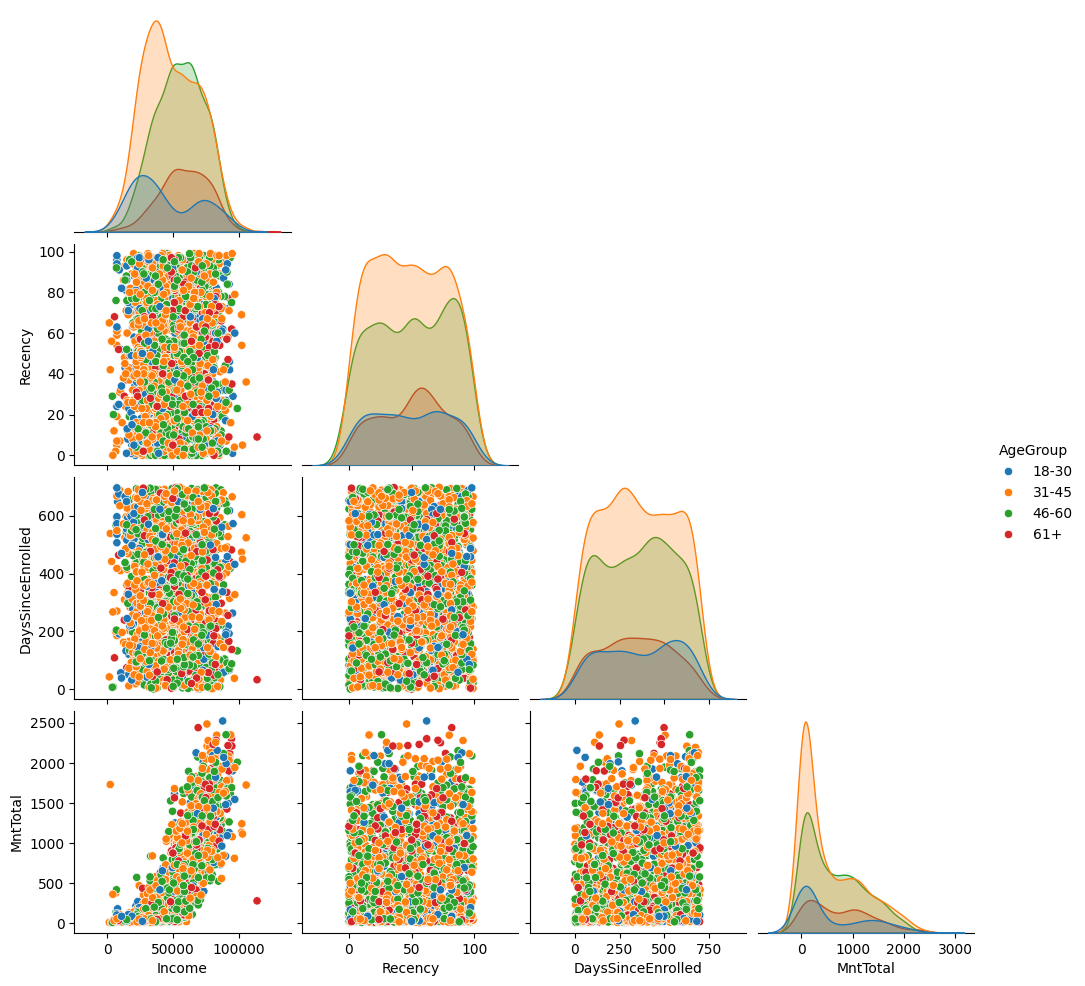

In [13]:
# Analisando pairplot para cada valor de AgeGroup

analysis_columns_without_age = analysis_columns.copy()
analysis_columns_without_age.pop(
    analysis_columns_without_age.index("Age")
)
pairplot(df, analysis_columns_without_age, "AgeGroup")

- Dois picos na distribuição em `Income` para registros da categoria '18-30' de `AgeGroup`
- Concentração em valores pequenos em `Income` para registros da categoria '31-45' de `AgeGroup`
- Concentração de registros da categoria '61+' de `AgeGroup` em valores próximos a 50 em `Recency`

A análise de boxplots também podem trazer alguns insights sobre a base.

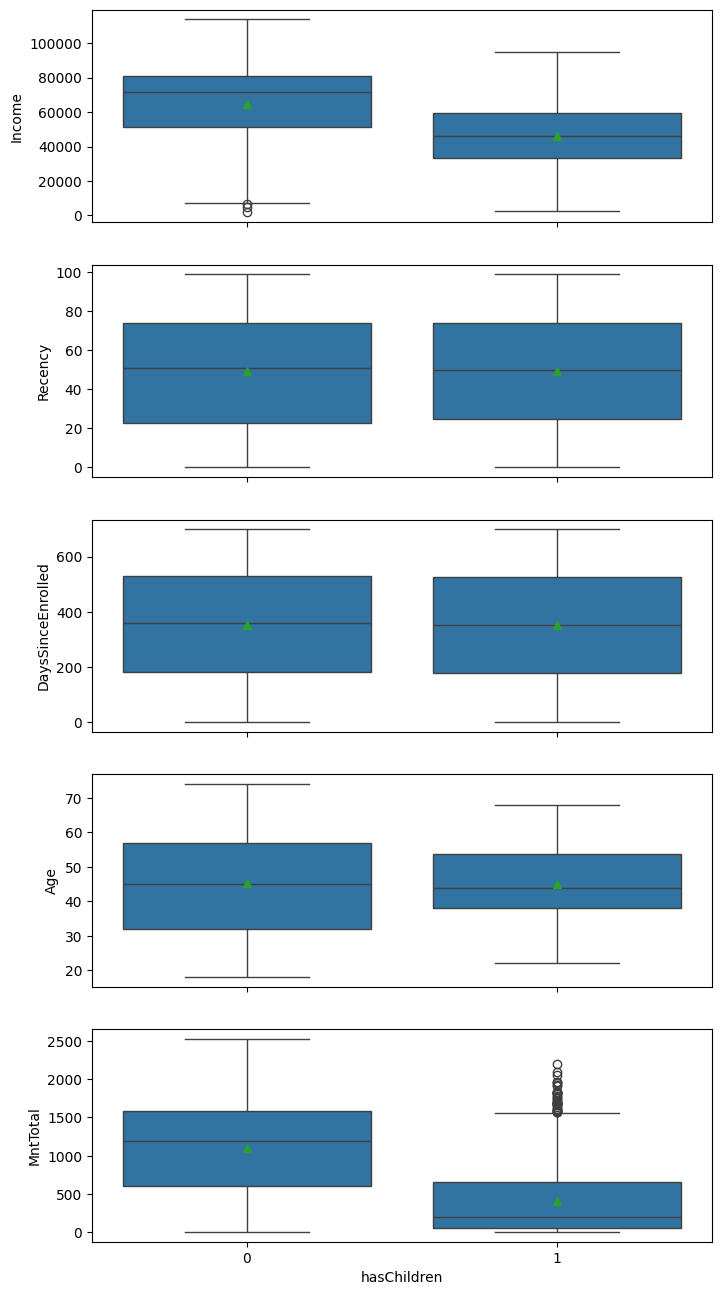

In [14]:
# Boxplot para hasChildren

plot_bivariate_boxplot(df, analysis_columns, "hasChildren")

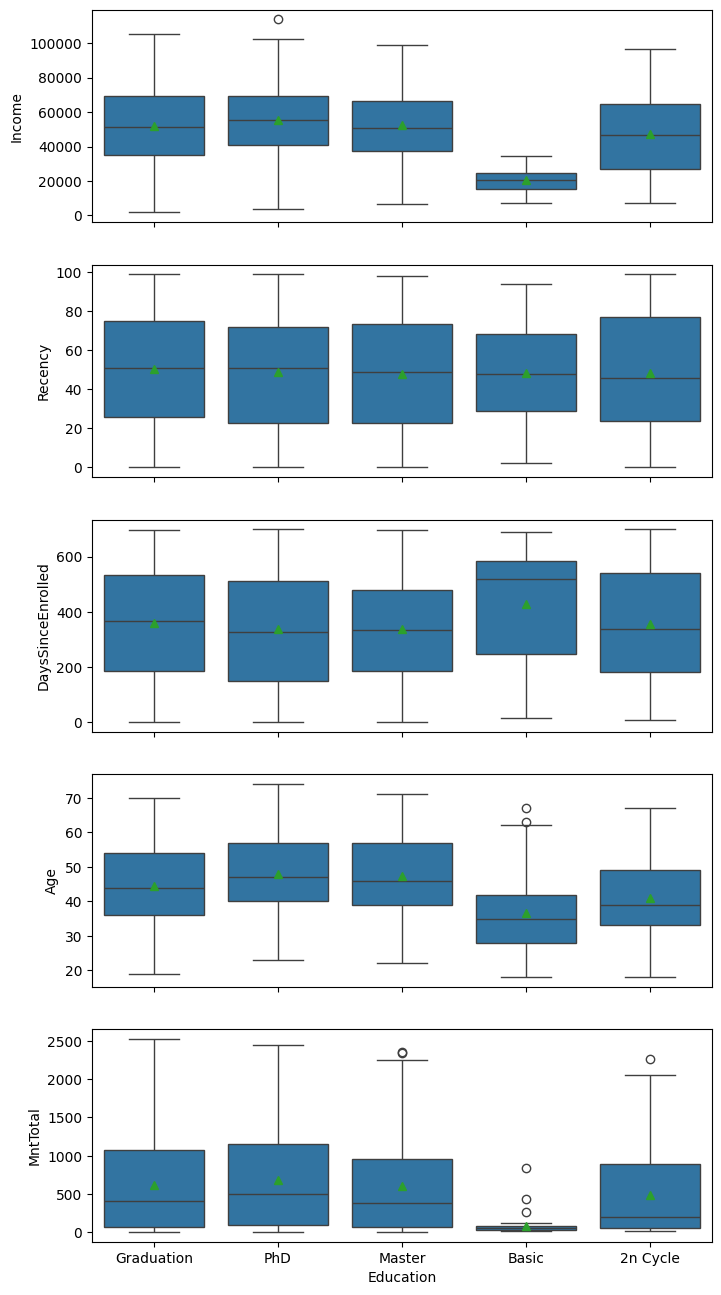

In [15]:
# Boxplot para Education

plot_bivariate_boxplot(df, analysis_columns, "Education")

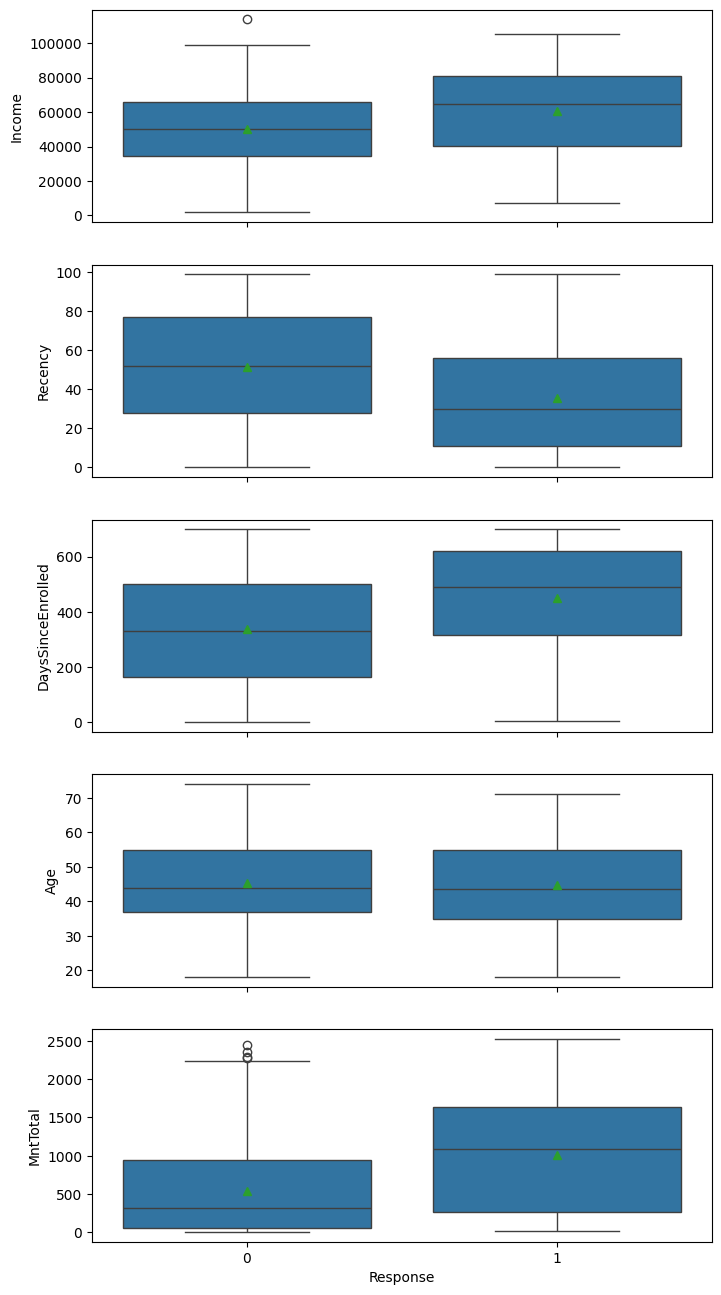

In [16]:
# Boxplot para Response

plot_bivariate_boxplot(df, analysis_columns, "Response")

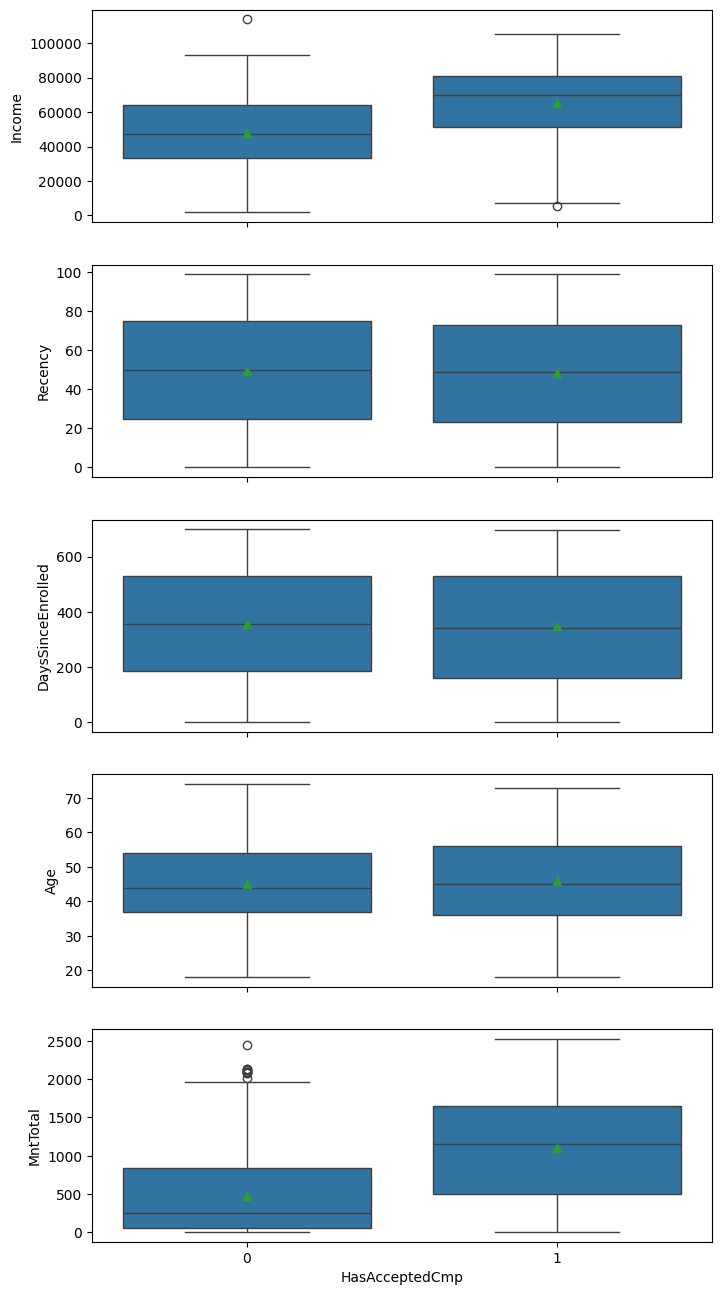

In [17]:
# Boxplot para HasAcceptedCmp

plot_bivariate_boxplot(df, analysis_columns, "HasAcceptedCmp")

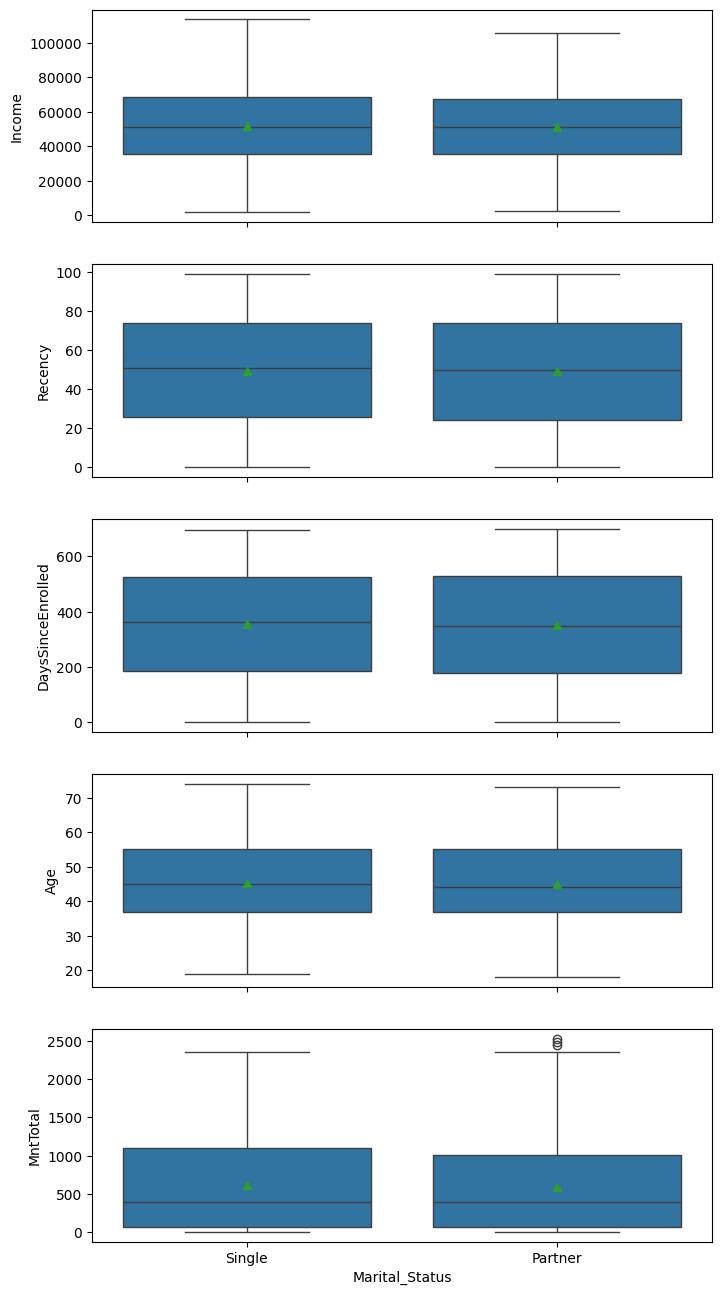

In [18]:
# Boxplot para Marital_Status

plot_bivariate_boxplot(df, analysis_columns, "Marital_Status")

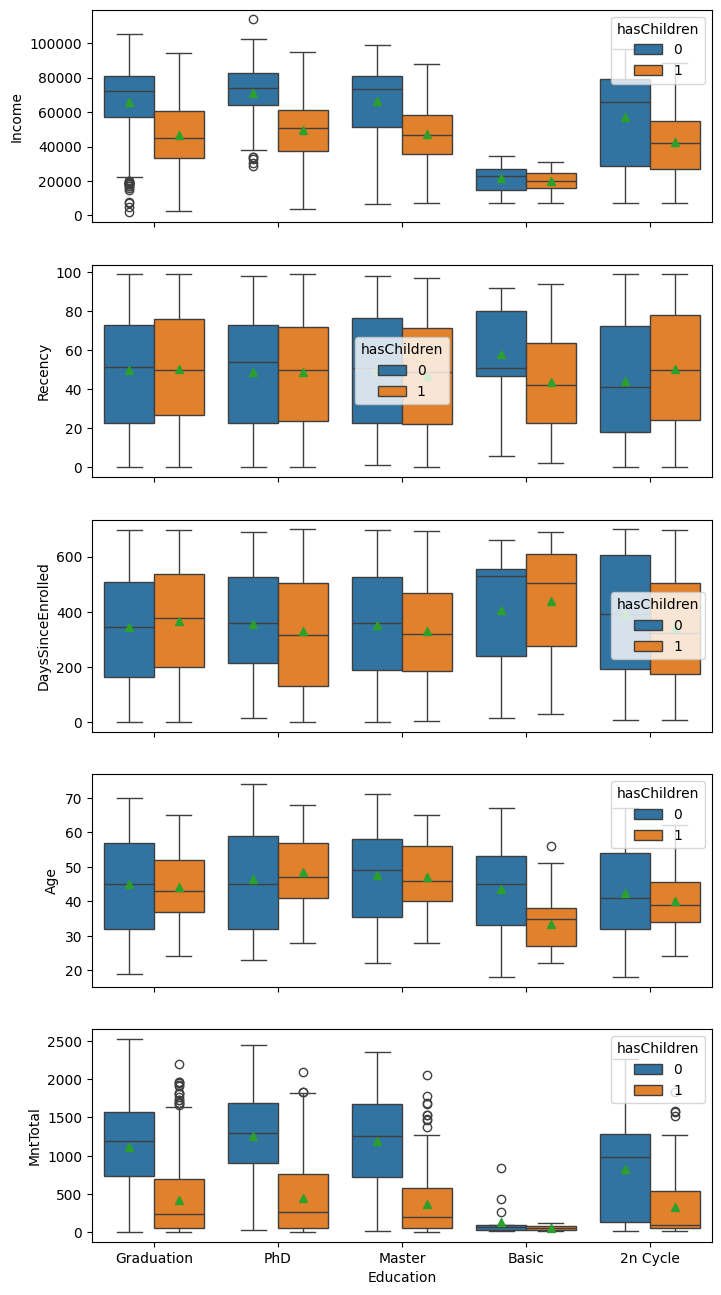

In [19]:
# Boxplot para Education e hasChildren
plot_bivariate_boxplot(df, analysis_columns, "Education", "hasChildren")

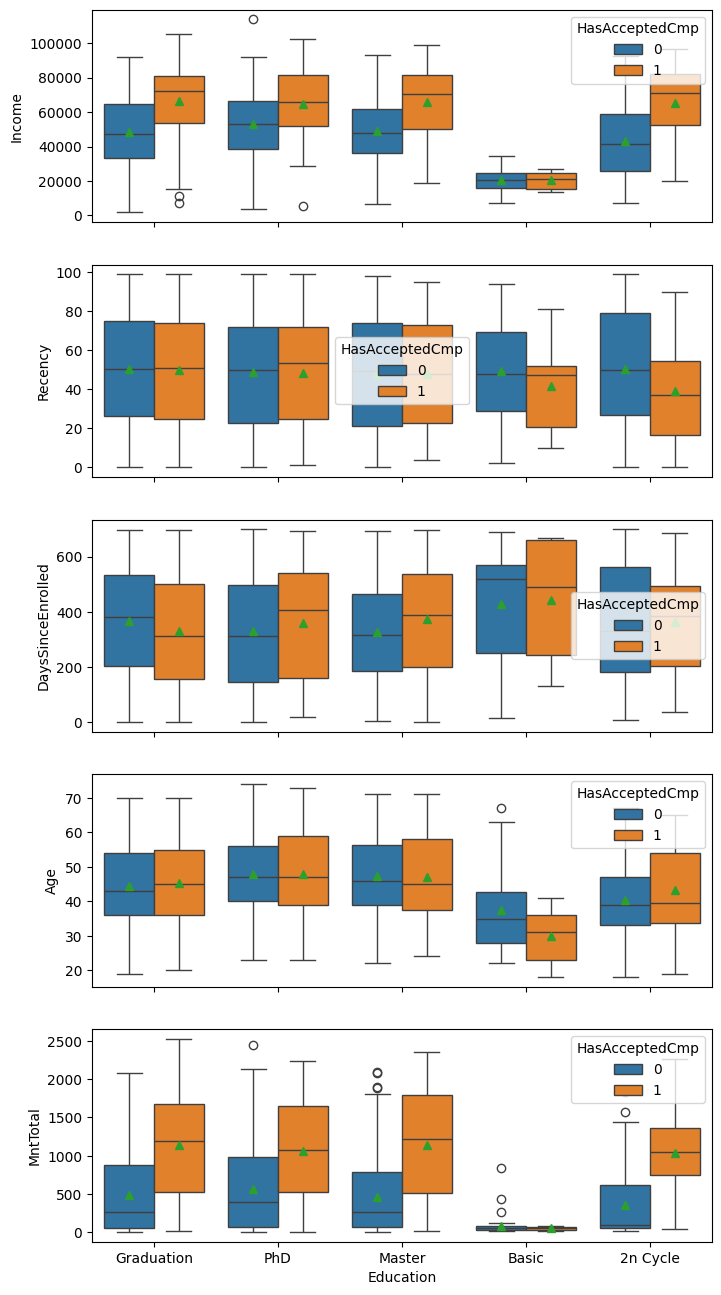

In [20]:
# Boxplot para Education e HasAcceptedCmp
plot_bivariate_boxplot(df, analysis_columns, "Education", "HasAcceptedCmp")

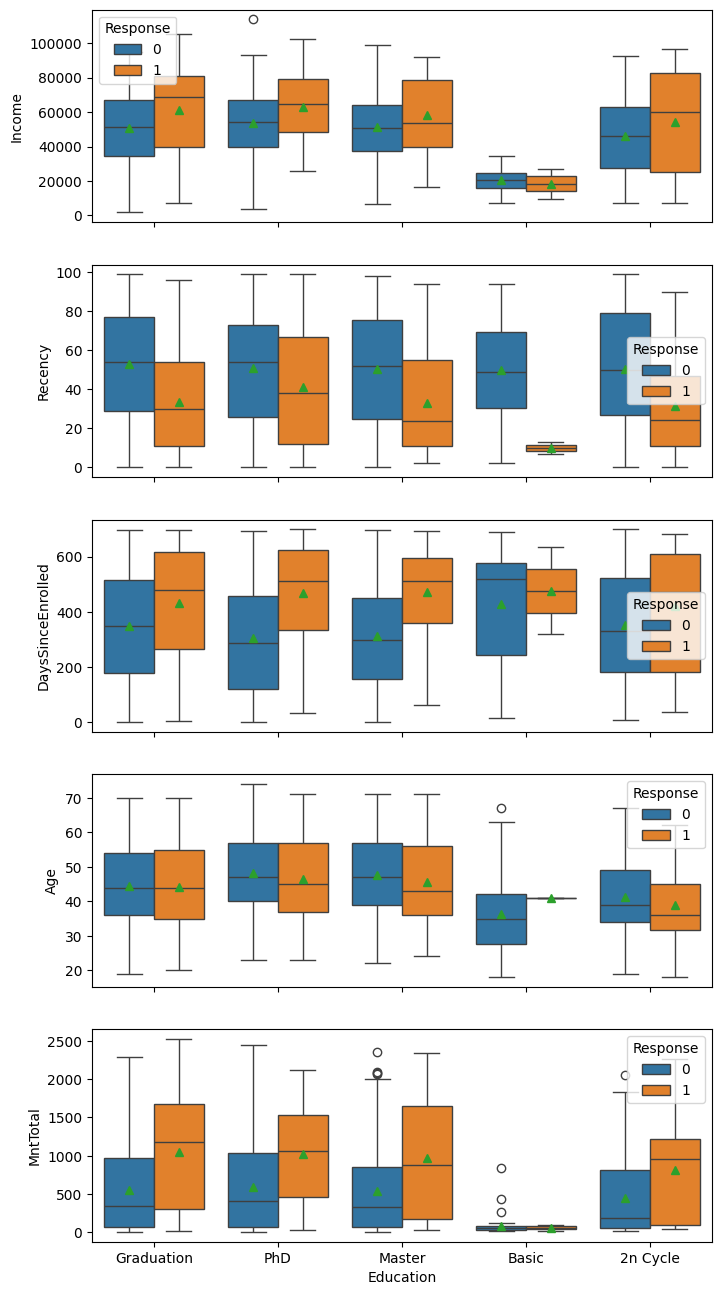

In [21]:
# Boxplot para Education e Response
plot_bivariate_boxplot(df, analysis_columns, "Education", "Response")

In [22]:
# Gerando dummies das colunas categóricas para matriz de correlação
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Partner,Marital_Status_Single,AgeGroup_18-30,AgeGroup_31-45,AgeGroup_46-60,AgeGroup_61+
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,True,False,False,False,True,False,False,True,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,True,False,False,False,True,False,False,True,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,True,False,False,True,False,False,False,True,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,True,False,False,True,False,True,False,False,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,False,True,True,False,False,True,False,False


In [23]:
# Salvando o DataFrame de dummies
df_dummies.to_csv(DUMMIES_DATA, index=False)

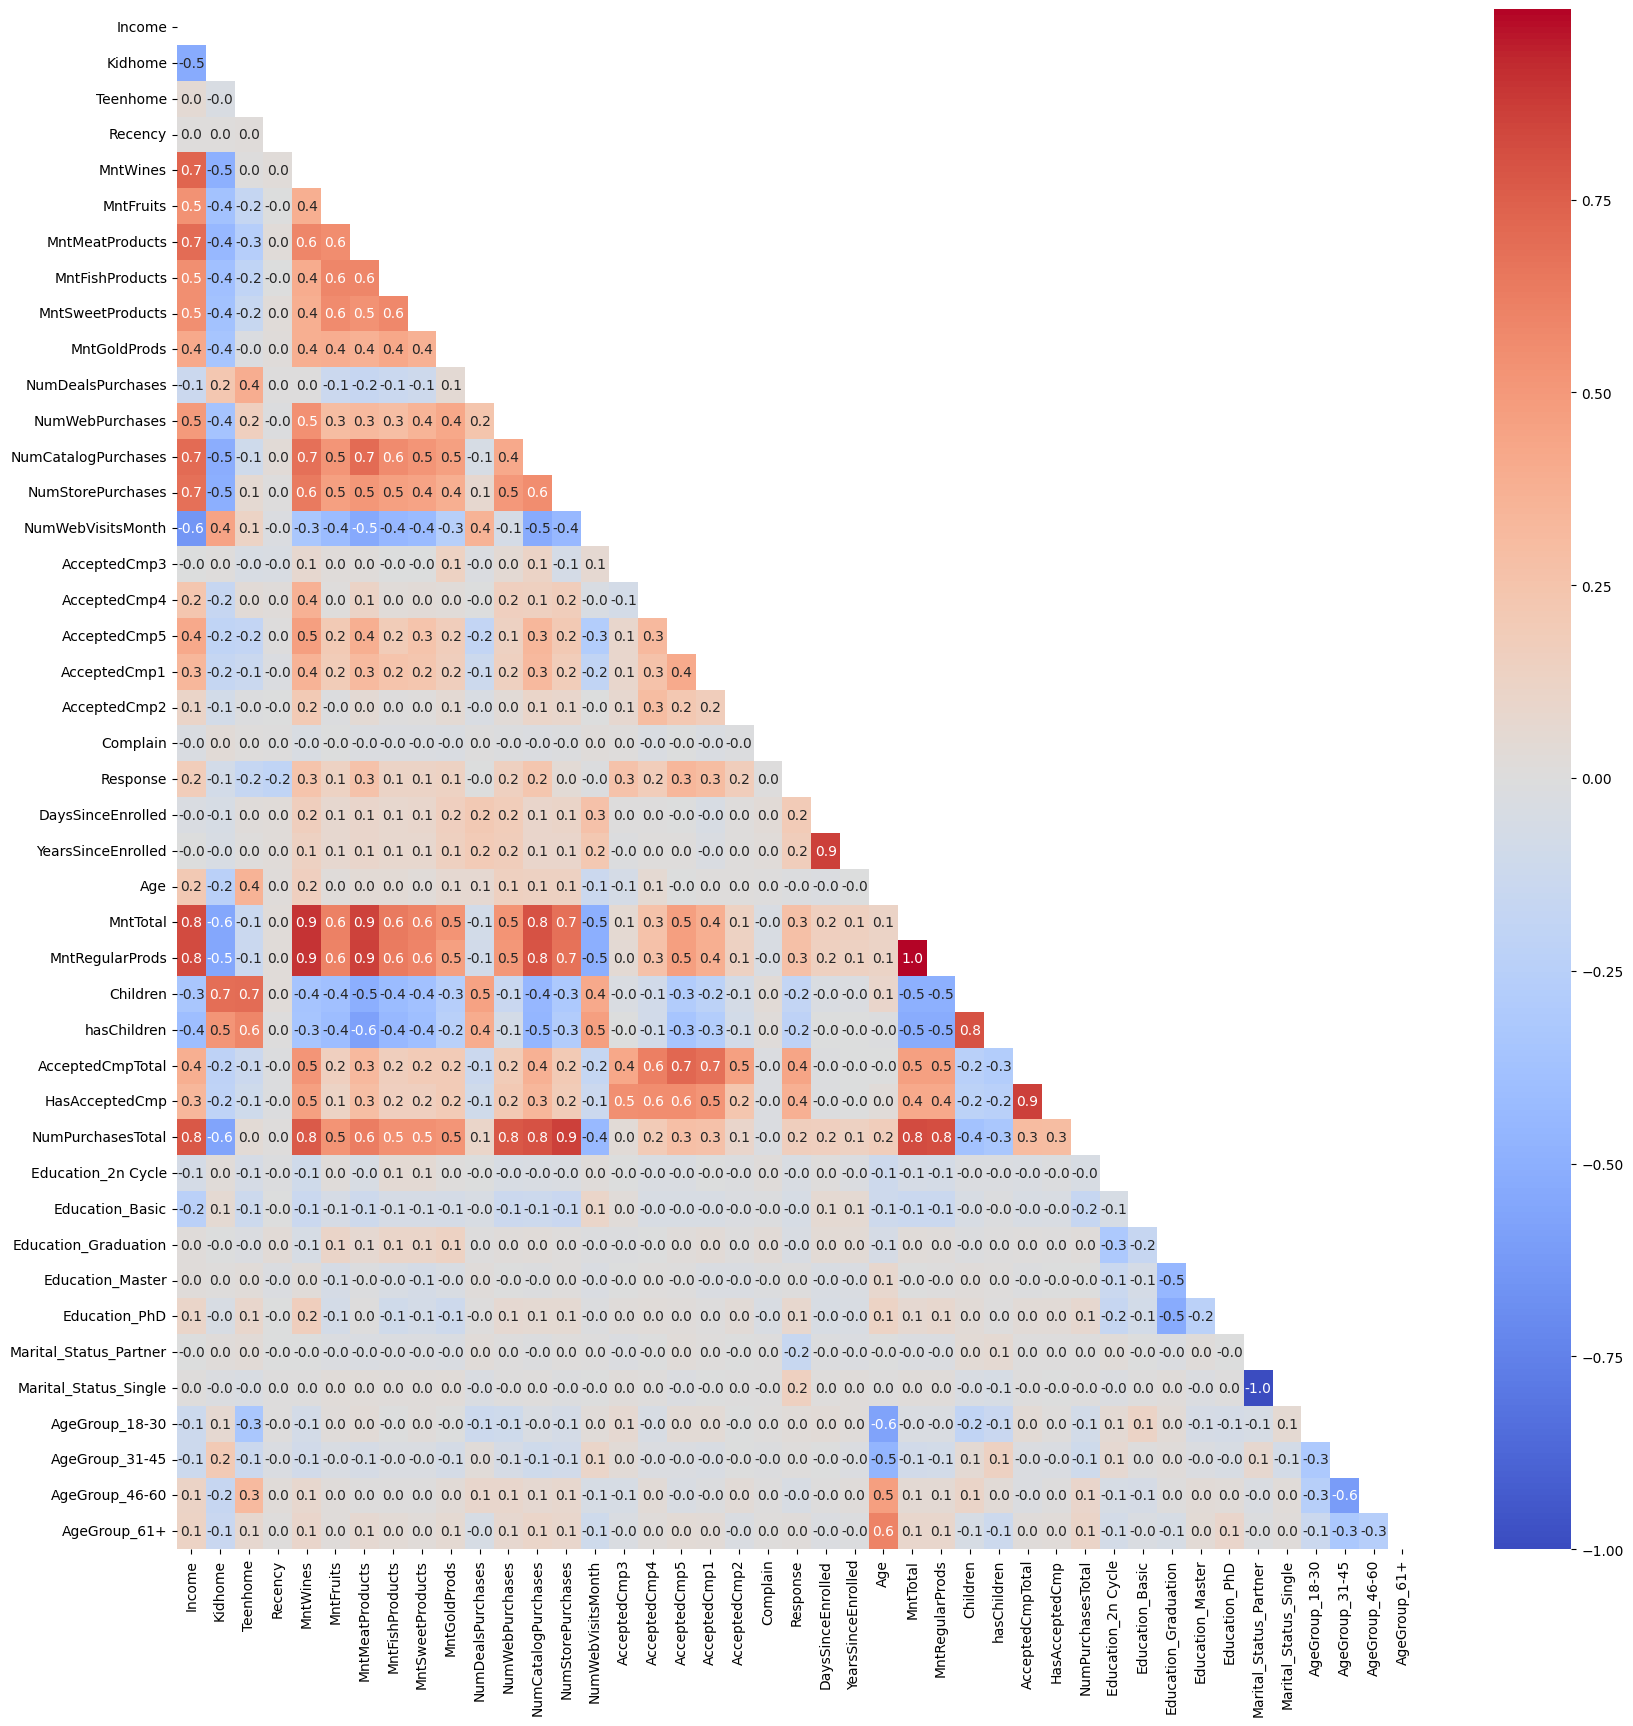

In [24]:
# Matriz de correlação
df_corr = df_dummies.corr()

mask = np.triu(df_corr)

fig, ax = plt.subplots(figsize=(20, 20))

sns.heatmap(
    df_corr,
    mask=mask,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    ax=ax,
)

plt.show()

In [25]:
# Armanezando o dataframe de correlação empilhado em uma variável

df_corr_stack = pd.DataFrame(df_corr.stack(), columns=["corr"])
df_corr_stack.head()

corr
Income Income    1.000000
       Kidhome  -0.524261
       Teenhome  0.047560
       Recency   0.009403
       MntWines  0.729957

In [26]:
# Verificando a correlação de Income com as demais colunas
df_corr_stack.loc["Income"].sort_values(by="corr")

,corr
NumWebVisitsMonth,-0.643088
Kidhome,-0.524261
hasChildren,-0.403784
Children,-0.341605
Education_Basic,-0.241391
NumDealsPurchases,-0.131669
AgeGroup_18-30,-0.122842
AgeGroup_31-45,-0.119000
Education_2n Cycle,-0.067600
Complain,-0.027616


In [27]:
# Verificando a correlação de Age com as demais colunas
df_corr_stack.loc["Age"].sort_values(by="corr")

,corr
AgeGroup_18-30,-0.577568
AgeGroup_31-45,-0.468527
Kidhome,-0.235949
NumWebVisitsMonth,-0.126622
Education_Basic,-0.117071
Education_2n Cycle,-0.114757
AcceptedCmp3,-0.066318
Education_Graduation,-0.058332
DaysSinceEnrolled,-0.023944
hasChildren,-0.015020


In [28]:
# Verificando a correlação de Recency com as demais colunas
df_corr_stack.loc["Recency"].sort_values(by="corr")

,corr
Response,-0.197379
AcceptedCmp3,-0.032746
AgeGroup_31-45,-0.029665
Education_Master,-0.022620
AcceptedCmp1,-0.021212
NumWebVisitsMonth,-0.018971
HasAcceptedCmp,-0.016503
AcceptedCmpTotal,-0.013967
NumWebPurchases,-0.011672
Education_2n Cycle,-0.009487


In [29]:
# Verificando a correlação de DaysSinceEnrolled com as demais colunas
df_corr_stack.loc["DaysSinceEnrolled"].sort_values(by="corr")

,corr
Kidhome,-0.053059
AcceptedCmp1,-0.045756
Education_PhD,-0.041481
Education_Master,-0.035948
Income,-0.027339
Children,-0.026926
Age,-0.023944
AgeGroup_61+,-0.023133
AcceptedCmpTotal,-0.013597
HasAcceptedCmp,-0.012947


In [30]:
# Verificando a correlação de MntTotal com as demais colunas
df_corr_stack.loc["MntTotal"].sort_values(by="corr")

,corr
Kidhome,-0.555073
hasChildren,-0.522717
NumWebVisitsMonth,-0.502127
Children,-0.496391
Education_Basic,-0.138793
Teenhome,-0.135224
AgeGroup_31-45,-0.088075
NumDealsPurchases,-0.080549
Education_2n Cycle,-0.062105
Complain,-0.034095


In [31]:
# Verificando a correlação de Response com as demais colunas
df_corr_stack.loc["Response"].sort_values(by="corr")

,corr
hasChildren,-0.217234
Recency,-0.197379
Children,-0.181316
Teenhome,-0.165818
Marital_Status_Partner,-0.152796
Kidhome,-0.084956
Education_Basic,-0.048342
AgeGroup_46-60,-0.041038
Education_2n Cycle,-0.037733
Education_Graduation,-0.035994


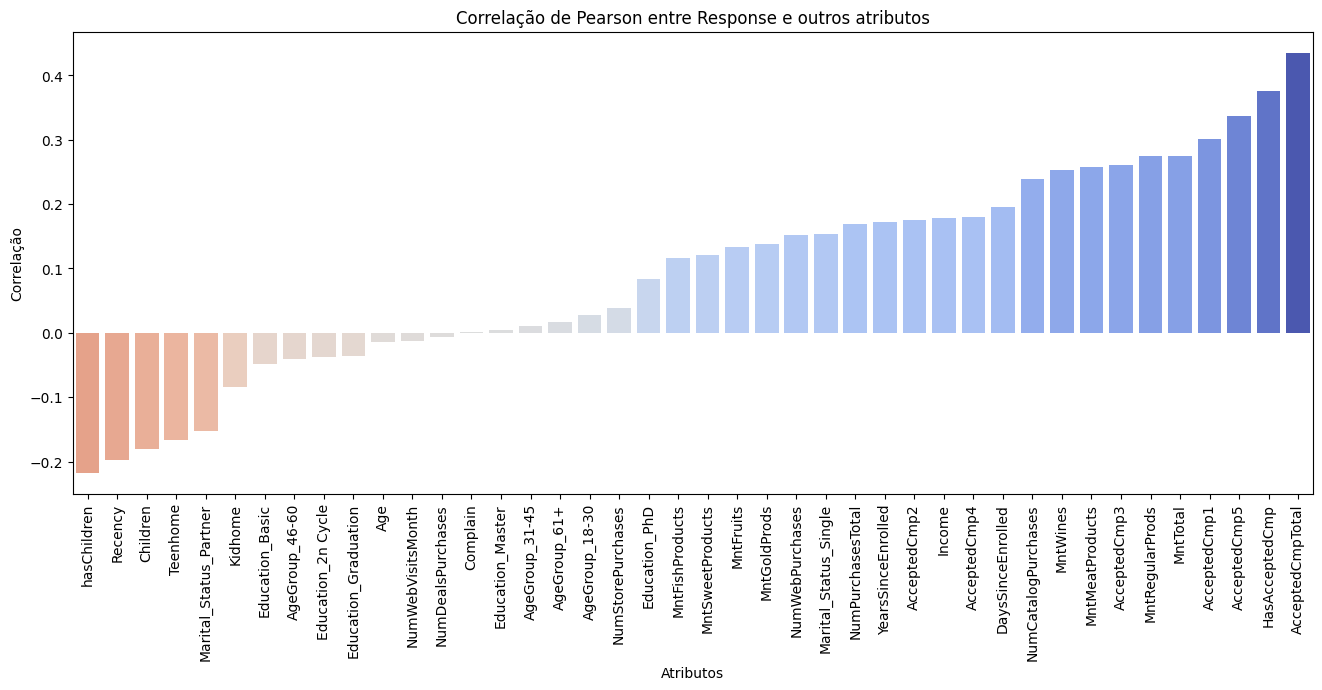

In [32]:
# Verificando a correlação de Response com os outros atributos
plot_corr_barplot(df_dummies, "Response")

In [33]:
# Salvando as mudanças
df.to_parquet(CLEANED_DATA, index=False)